In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [7]:
pd.to_numeric(df['TotalCharges'], errors='coerce').isnull().sum()

np.int64(11)

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [11]:
df.dtypes 

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [12]:
df['Churn_flag'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [14]:
df.to_csv('telco_churn_cleaned.csv', index=False) 

In [15]:
df.groupby('Contract')['Churn_flag'].mean() * 100 

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn_flag, dtype: float64

In [16]:
df.groupby('PaymentMethod')['Churn_flag'].mean() * 100 

PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn_flag, dtype: float64

In [17]:
df.groupby('InternetService')['Churn_flag'].mean() * 100 

InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn_flag, dtype: float64

In [20]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,36,48,60,72], labels=['0-1nam','1-2nam','2-3nam','3-4nam','4-5nam','5-6nam'])
df.groupby('tenure_group', observed=True)['Churn_flag'].mean() * 100

tenure_group
0-1nam    47.678161
1-2nam    28.710938
2-3nam    21.634615
3-4nam    19.028871
4-5nam    14.423077
5-6nam     6.609808
Name: Churn_flag, dtype: float64

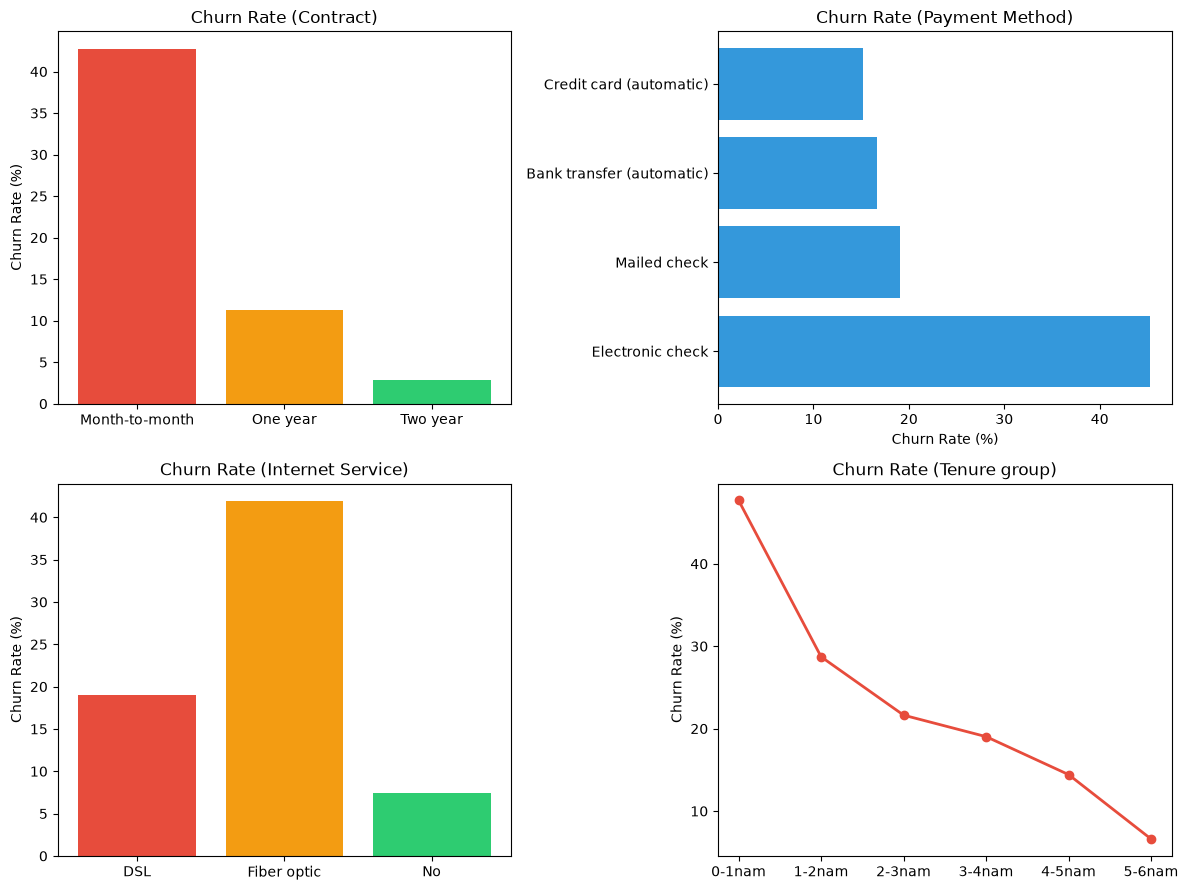

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Bieu do 1: Contract
contract_churn = df.groupby('Contract')['Churn_flag'].mean() * 100
axes[0,0].bar(contract_churn.index, contract_churn.values, color=['#e74c3c','#f39c12','#2ecc71'])
axes[0,0].set_title('Churn Rate (Contract)')
axes[0,0].set_ylabel('Churn Rate (%)')

# Bieu do 2: Payment Method
pay_churn = df.groupby('PaymentMethod')['Churn_flag'].mean().sort_values(ascending=False) * 100
axes[0,1].barh(pay_churn.index, pay_churn.values, color='#3498db')
axes[0,1].set_title('Churn Rate (Payment Method)')
axes[0,1].set_xlabel('Churn Rate (%)')

# Bieu do 3: Internet Service
net_churn = df.groupby('InternetService')['Churn_flag'].mean() * 100
axes[1,0].bar(net_churn.index, net_churn.values, color=['#e74c3c','#f39c12','#2ecc71'])
axes[1,0].set_title('Churn Rate (Internet Service)')
axes[1,0].set_ylabel('Churn Rate (%)')

# Bieu do 4: Tenure group
tenure_churn = df.groupby('tenure_group', observed=True)['Churn_flag'].mean() * 100
axes[1,1].plot(tenure_churn.index, tenure_churn.values, marker='o', color='#e74c3c', linewidth=2)
axes[1,1].set_title('Churn Rate (Tenure group)')
axes[1,1].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('churn_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()